## **Assignment 02**

#### **01. Blob Detection**

In [38]:
#import required libraries
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_laplace, maximum_filter

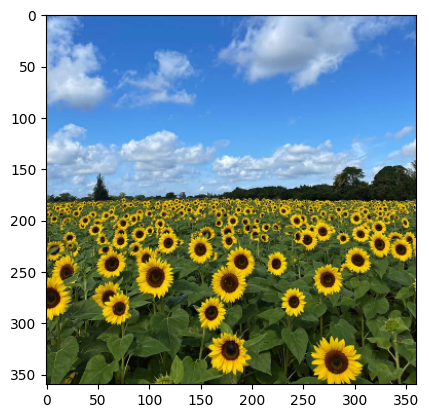

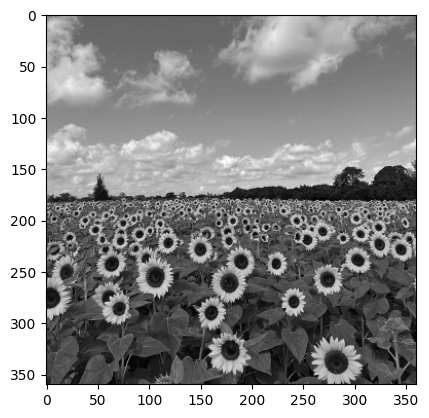

In [ ]:
#Read image reducing resolution by factor 4
sunflower_img = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4) 
plt.imshow(sunflower_img[:,:,::-1])
plt.show()

#Convert the image into GrayScale
sunflower_gray = cv.cvtColor(sunflower_img, cv.COLOR_BGR2GRAY) / 255
plt.imshow(sunflower_gray, cmap='gray')
plt.show()

**Gaussian Filter derivation**

In [74]:
X, Y = np.meshgrid(np.arange(-2,3), np.arange(-2,3))
sigma = 1
gaussian = (1/(2*np.pi*sigma**2))*np.exp(-(X**2+Y**2)/(2*sigma**2))
min =np.min((gaussian))
print(np.round(gaussian/min).astype(int))

[[ 1  4  7  4  1]
 [ 4 20 33 20  4]
 [ 7 33 55 33  7]
 [ 4 20 33 20  4]
 [ 1  4  7  4  1]]


In [75]:
G = []
margins = [-2.5,-1.5, -0.5, 0.5, 1.5,2.5]
for j in range(5):
  g = [] 
  for i in range(5):
    X, Y = np.meshgrid(np.arange(margins[i],margins[i+1]+0.001,0.001), np.arange(margins[j],margins[j+1]+0.001,0.001))
    sigma = 1
    gaussian = (1/(2*np.pi*sigma**2))*np.exp(-(X**2+Y**2)/(2*sigma**2))
    g.append(np.sum(gaussian))
  G.append(g)

print(np.round(G/np.min(G)).astype(int))


[[ 1  4  6  4  1]
 [ 4 16 25 16  4]
 [ 6 25 40 25  6]
 [ 4 16 25 16  4]
 [ 1  4  6  4  1]]


### **Blob Detection (Method 01)**

In [ ]:
#Sigma values
min_sigma = 1
max_sigma = 20
num_scales = 8
k = np.sqrt(2)
sigmas = [min_sigma * (k ** i) for i in range(num_scales)]
print(sigmas)

#Scale space
rows, cols = sunflower_gray.shape
scale_space = np.zeros((num_scales, rows, cols), dtype=np.float32)
sc_sp = np.zeros((num_scales, rows, cols), dtype=np.float32)

for i, sigma in enumerate(sigmas):
  laplacian_of_gaussian = gaussian_laplace(sunflower_gray, sigma)
  scale_space[i] = (sigma**2) * np.abs(laplacian_of_gaussian)

  gaussian = cv.GaussianBlur(sunflower_gray, (0,0), sigma)
  laplacian = cv.Laplacian(gaussian, cv.CV_64F)
  lap_of_g = (sigma**2) * np.abs(laplacian)

  plt.figure(figsize=(20,8))
  plt.subplot(1,2,1)
  plt.imshow(scale_space[i], cmap='gray')
  plt.title(f'Lapacian of Gaussian (Scipy.ndimage) sigma = {sigma}')

  plt.subplot(1,2,2)
  plt.imshow(lap_of_g, cmap='gray')
  plt.title(f'Gaussianblur + Laplacian (OpenCV) sigma = {sigma}')
  plt.show()


threshold = 0.03 * scale_space.max()
blobs = []

for i in range(num_scales):
  max_f = maximum_filter(scale_space[i], size=3)
  mask = (scale_space[i] == max_f) & (scale_space[i]>threshold)
  ys, xs = np.nonzero(mask)
  for y, x in zip(ys, xs):
    blobs.append((x, y, sigmas[i], scale_space[i, y, x]))

blobs = sorted(blobs, key=lambda b: b[3], reverse=True)
final = []

for x, y, s, val in blobs:
    r = np.sqrt(2) * s
    if all(np.hypot(x - fx, y - fy) > 0.5 * (r + np.sqrt(2) * fs) for fx, fy, fs, fv in final):
        final.append((x, y, s, val))

print(f"Detected blobs: {len(final)}")

out = sunflower_img.copy()
# show top 50 blobs
for x, y, s, val in final[:50]:  
    r = int(np.sqrt(2) * s)
    cv.circle(out, (int(x), int(y)), r, (0, 0, 255), 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(out, cv.COLOR_BGR2RGB))
plt.title(f"Detected Sunflower Blobs ({len(final)} total)")
plt.axis('off')
plt.show()


In [109]:
cv.imwrite('blob deteced image.png', out)

True

Image shape: (360, 360, 3)

Sigma range: 3.00 to 25.00
Sigma values: ['3.00', '4.24', '6.00', '8.49', '12.00', '16.97', '24.00', '33.94', '48.00', '67.88', '96.00', '135.76']

=== Computing Scale-Space ===
Sigma 3.00: max response = 0.392012
Sigma 4.24: max response = 0.371136
Sigma 6.00: max response = 0.363568
Sigma 8.49: max response = 0.314374
Sigma 12.00: max response = 0.246149
Sigma 16.97: max response = 0.226648
Sigma 24.00: max response = 0.192546
Sigma 33.94: max response = 0.143917
Sigma 48.00: max response = 0.138973
Sigma 67.88: max response = 0.123763
Sigma 96.00: max response = 0.127236
Sigma 135.76: max response = 0.132829

=== Finding Blobs ===
Found 160 blobs initially

=== Non-Maximum Suppression ===
Final blob count: 141

LARGEST DETECTED CIRCLES (Top 10)
Rank          Y        X    Sigma   Radius   Response
----------------------------------------------------------------------
1         239.0    303.0     4.24     6.00     0.3711
2         290.0    161.0     4.24  

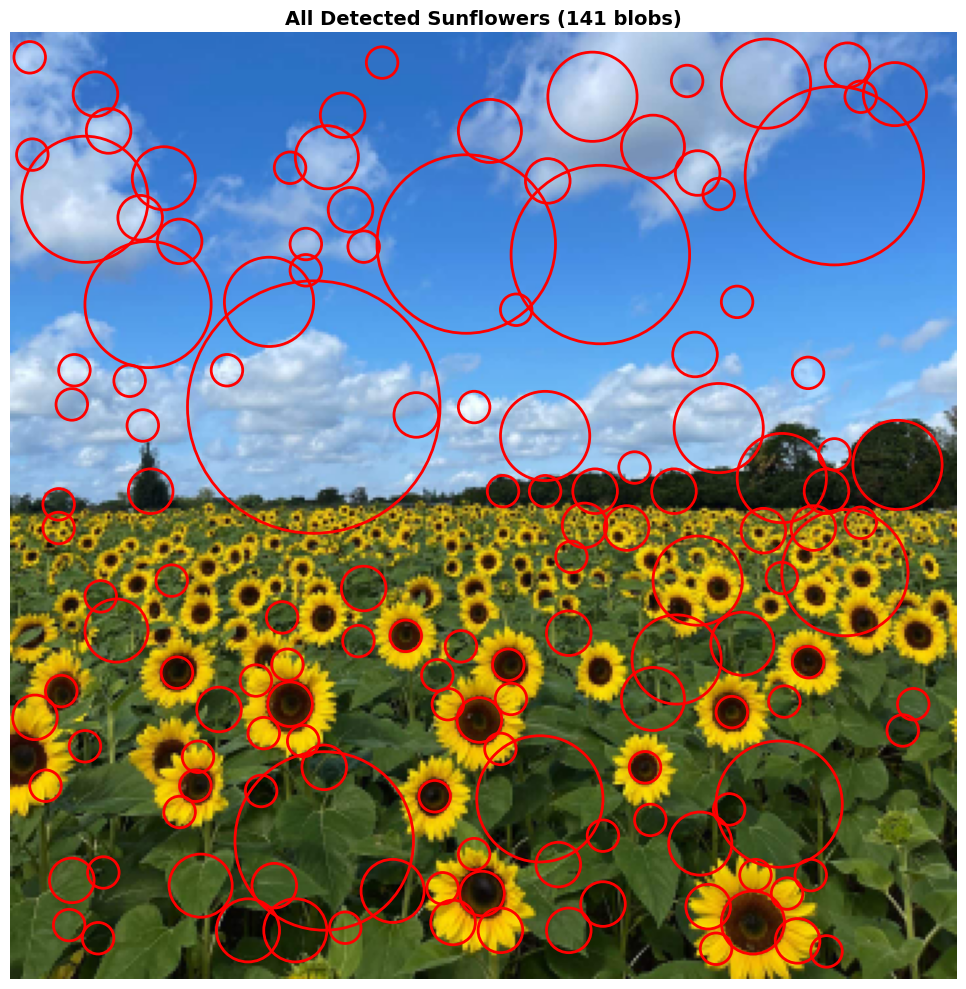

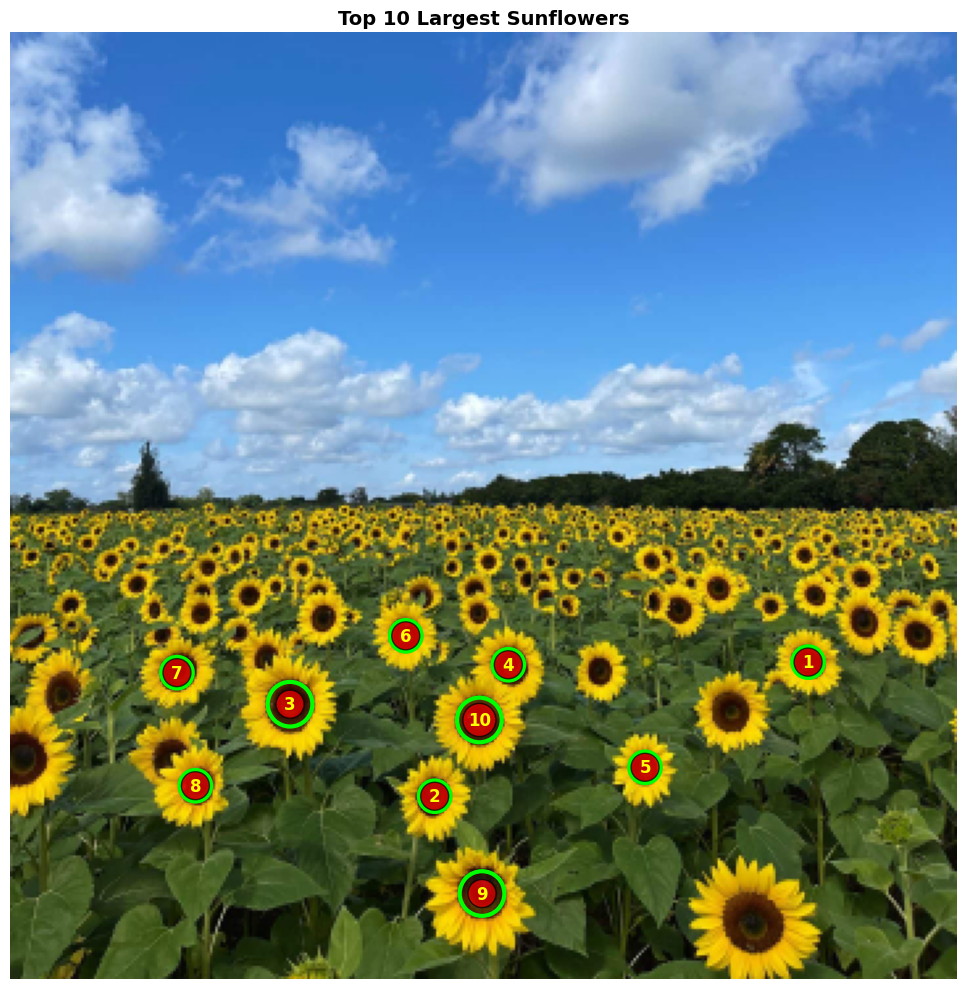

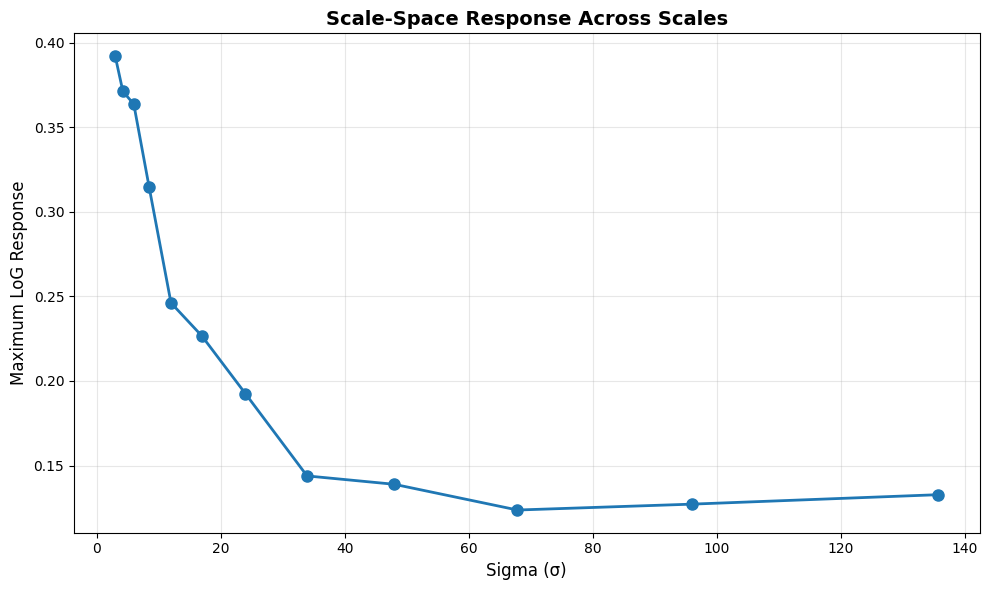


=== Summary ===
Sigma range used: 3.00 to 135.76
Number of scales: 12
Total circles detected: 141
Largest circle: radius = 6.00 pixels

Images saved: all_sunflowers.png, top10_sunflowers.png, scale_space_response.png


In [62]:
"""
Question 1: Simple Blob Detection using Laplacian of Gaussian (LoG)
Detects circular blobs (sunflowers) in the image
"""

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_laplace

# Load the sunflower image
im = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
print(f"Image shape: {im.shape}")

# Convert to grayscale and normalize to [0,1]
gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)
gray = gray.astype(np.float32) / 255.0

# Define sigma values for scale-space
min_sigma = 3
max_sigma = 25
num_sigma = 12
k = np.sqrt(2)  # Scale factor between consecutive sigmas
sigmas = [min_sigma * (k ** i) for i in range(num_sigma)]

print(f"\nSigma range: {min_sigma:.2f} to {max_sigma:.2f}")
print(f"Sigma values: {[f'{s:.2f}' for s in sigmas]}")

# Step 1: Build scale-space by computing LoG at different scales
print("\n=== Computing Scale-Space ===")
rows, cols = gray.shape
scale_space = np.zeros((num_sigma, rows, cols))

for i, sigma in enumerate(sigmas):
    # Compute Laplacian of Gaussian
    log_response = gaussian_laplace(gray, sigma)
    
    # Normalize by sigma^2 (CRITICAL for scale invariance!)
    scale_space[i] = (sigma ** 2) * np.abs(log_response)
    
    print(f"Sigma {sigma:.2f}: max response = {scale_space[i].max():.6f}")

# Step 2: Find local maxima in scale-space (blob centers)
print("\n=== Finding Blobs ===")

threshold = 0.005 * scale_space.max()  # Threshold for blob detection
blobs = []

# Check each point in scale-space (avoid borders)
for s in range(1, num_sigma - 1):
    for i in range(5, rows - 5):
        for j in range(5, cols - 5):
            # Check if above threshold
            if scale_space[s, i, j] < threshold:
                continue
            
            # Check if it's a local maximum in 3x3x3 neighborhood
            neighborhood = scale_space[s-1:s+2, i-5:i+6, j-5:j+6]
            
            if scale_space[s, i, j] == neighborhood.max():
                # Found a blob! Store (y, x, sigma, response)
                blobs.append((i, j, sigmas[s], scale_space[s, i, j]))

print(f"Found {len(blobs)} blobs initially")

# Step 3: Non-maximum suppression (remove overlapping blobs)
print("\n=== Non-Maximum Suppression ===")

# Sort by response strength (strongest first)
blobs = sorted(blobs, key=lambda x: x[3], reverse=True)

final_blobs = []
for blob in blobs:
    y, x, sigma, response = blob
    radius = sigma * np.sqrt(2)  # Blob radius
    
    # Check if too close to already accepted blob
    keep = True
    for existing in final_blobs:
        ey, ex, esigma, _ = existing
        eradius = esigma * np.sqrt(2)
        
        # Distance between centers
        dist = np.sqrt((y - ey)**2 + (x - ex)**2)
        
        # If overlapping too much, discard
        if dist < 0.6 * (radius + eradius):
            keep = False
            break
    
    if keep:
        final_blobs.append(blob)

print(f"Final blob count: {len(final_blobs)}")

# Step 4: Report results
print("\n" + "="*70)
print("LARGEST DETECTED CIRCLES (Top 10)")
print("="*70)
print(f"{'Rank':<6} {'Y':>8} {'X':>8} {'Sigma':>8} {'Radius':>8} {'Response':>10}")
print("-"*70)

for idx, (y, x, sigma, response) in enumerate(final_blobs[:10]):
    radius = sigma * np.sqrt(2)
    print(f"{idx+1:<6} {y:>8.1f} {x:>8.1f} {sigma:>8.2f} {radius:>8.2f} {response:>10.4f}")

print(f"\nTotal circles detected: {len(final_blobs)}")

# Step 5: Visualize results
print("\n=== Creating Visualizations ===")

# Visualization 1: All detected blobs
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
ax.set_title(f'All Detected Sunflowers ({len(final_blobs)} blobs)', 
             fontsize=14, fontweight='bold')

for idx, (y, x, sigma, response) in enumerate(final_blobs):
    radius = sigma * np.sqrt(2)
    circle = plt.Circle((x, y), radius, color='red', fill=False, linewidth=2)
    ax.add_patch(circle)

ax.axis('off')
plt.tight_layout()
plt.savefig('all_sunflowers.png', dpi=200, bbox_inches='tight')
plt.show()

# Visualization 2: Top 10 largest sunflowers
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
ax.set_title('Top 10 Largest Sunflowers', fontsize=14, fontweight='bold')

for idx, (y, x, sigma, response) in enumerate(final_blobs[:10]):
    radius = sigma * np.sqrt(2)
    circle = plt.Circle((x, y), radius, color='lime', fill=False, linewidth=3)
    ax.add_patch(circle)
    
    # Add label
    ax.text(x, y, f'{idx+1}', color='yellow', fontsize=12, 
           ha='center', va='center', weight='bold',
           bbox=dict(boxstyle='circle', facecolor='red', alpha=0.7))

ax.axis('off')
plt.tight_layout()
plt.savefig('top10_sunflowers.png', dpi=200, bbox_inches='tight')
plt.show()

# Visualization 3: Scale-space response (optional)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
max_responses = [scale_space[i].max() for i in range(num_sigma)]
ax.plot(sigmas, max_responses, 'o-', linewidth=2, markersize=8)
ax.set_xlabel('Sigma (σ)', fontsize=12)
ax.set_ylabel('Maximum LoG Response', fontsize=12)
ax.set_title('Scale-Space Response Across Scales', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scale_space_response.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n=== Summary ===")
print(f"Sigma range used: {sigmas[0]:.2f} to {sigmas[-1]:.2f}")
print(f"Number of scales: {num_sigma}")
print(f"Total circles detected: {len(final_blobs)}")
print(f"Largest circle: radius = {final_blobs[0][2] * np.sqrt(2):.2f} pixels")
print("\nImages saved: all_sunflowers.png, top10_sunflowers.png, scale_space_response.png")

4805
Detected blobs: 1251


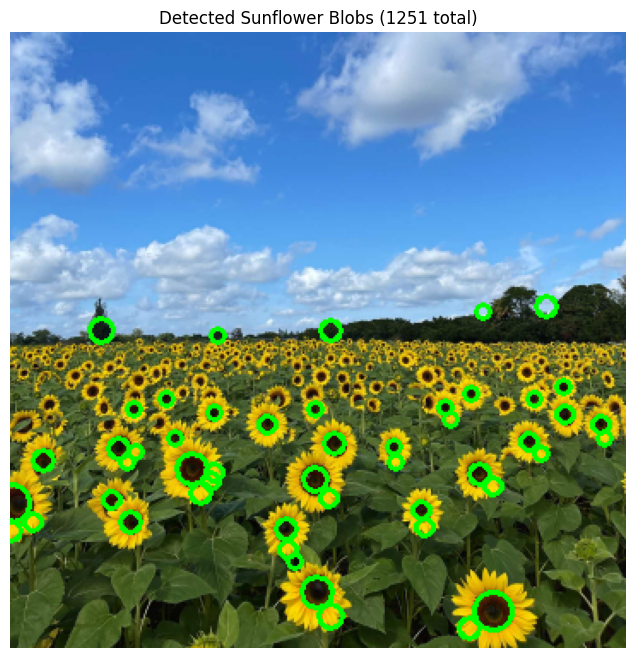

In [97]:
"""
Simple Blob Detection using Laplacian of Gaussian (LoG)
Detects circular blobs (sunflowers) in the image
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_laplace, maximum_filter

# 1. Load and preprocess image
img = cv2.imread('the_berry_farms_sunflower_field.jpeg', cv2.IMREAD_REDUCED_COLOR_4)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

# 2. Define sigma range (scale levels)
min_sigma, max_sigma, num_scales = 3, 25, 12
k = (max_sigma / min_sigma) ** (1 / (num_scales - 1))
sigmas = [min_sigma * (k ** i) for i in range(num_scales)]

# 3. Build scale-space using LoG (scale-normalized)
scale_space = np.zeros((num_scales, *gray.shape), dtype=np.float32)
for i, s in enumerate(sigmas):
    log_resp = gaussian_laplace(gray, sigma=s)
    scale_space[i] = (s ** 2) * np.abs(log_resp)

# 4. Find local maxima in scale-space
threshold = 0.03 * scale_space.max()
blobs = []
for i in range(num_scales):
    max_f = maximum_filter(scale_space[i], size=3)
    mask = (scale_space[i] == max_f) & (scale_space[i] > threshold)
    ys, xs = np.nonzero(mask)
    for y, x in zip(ys, xs):
        blobs.append((x, y, sigmas[i], scale_space[i, y, x]))

# 5. Remove overlapping blobs (keep strongest)
blobs = sorted(blobs, key=lambda b: b[3], reverse=True)

print(len(blobs))
final = []
for x, y, s, val in blobs:
    r = np.sqrt(2) * s
    if all(np.hypot(x - fx, y - fy) > 0.5 * (r + np.sqrt(2) * fs) for fx, fy, fs, fv in final):
        final.append((x, y, s, val))

print(f"Detected blobs: {len(final)}")

# 6. Draw detected blobs on the image
out = img.copy()
for x, y, s, val in final[:50]:  # show top 50 blobs
    r = int(np.sqrt(2) * s)
    cv2.circle(out, (int(x), int(y)), r, (0, 255, 0), 2)

# 7. Display results
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Sunflower Blobs ({len(final)} total)")
plt.axis('off')
plt.show()


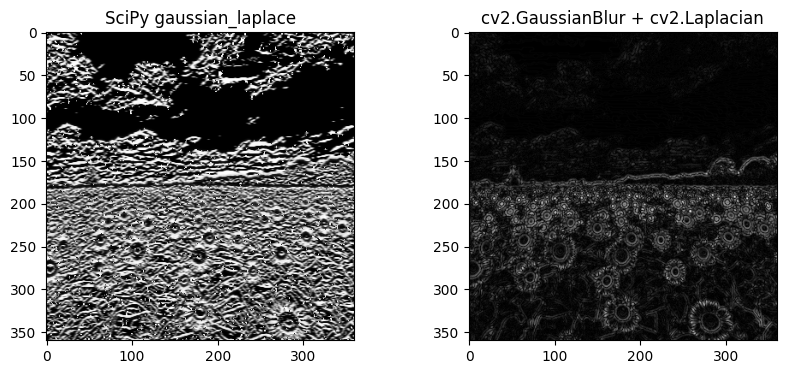

In [48]:
# Method 1: SciPy LoG
log_scipy = gaussian_laplace(sunflower_gray, sigma=1)

# Method 2: OpenCV Gaussian + Laplacian
blur = cv.GaussianBlur(sunflower_gray, (0,0), 1)
lap = cv.Laplacian(blur, cv.CV_64F)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(np.abs(log_scipy), cmap='gray'); plt.title('SciPy gaussian_laplace')
plt.subplot(1,2,2); plt.imshow(np.abs(lap), cmap='gray'); plt.title('cv2.GaussianBlur + cv2.Laplacian')
plt.show()

**Laplacian of Gaussian** 
   
The Laplacian of Gaussian is given by,  
  
 $\nabla^2 G(x, y) = \frac{\partial^2 G}{\partial x^2} + \frac{\partial^2 G}{\partial y^2}$.  
   
 $LoG(x,y) =\frac{1}{\pi \sigma^4}
\left[
1 - \frac{x^2 + y^2}{2\sigma^2}
\right]
e^{-\frac{x^2 + y^2}{2\sigma^2}}$




0.49 3
[[-0.27140848 -0.74486332 -0.27140848]
 [-0.74486332  5.521611   -0.74486332]
 [-0.27140848 -0.74486332 -0.27140848]]


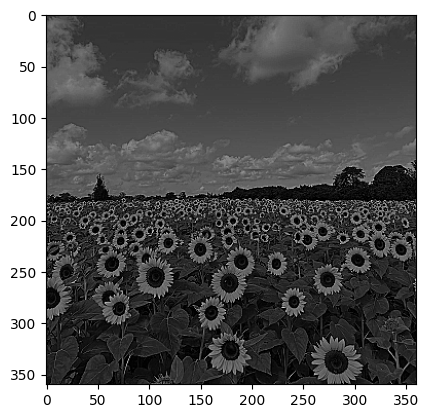

1 7
[[-3.14260486e-04 -2.63207757e-03 -8.57902057e-03 -1.23763620e-02
  -8.57902057e-03 -2.63207757e-03 -3.14260486e-04]
 [-2.63207757e-03 -1.74901468e-02 -3.91926999e-02 -4.30785586e-02
  -3.91926999e-02 -1.74901468e-02 -2.63207757e-03]
 [-8.57902057e-03 -3.91926999e-02  0.00000000e+00  9.65323526e-02
   0.00000000e+00 -3.91926999e-02 -8.57902057e-03]
 [-1.23763620e-02 -4.30785586e-02  9.65323526e-02  3.18309886e-01
   9.65323526e-02 -4.30785586e-02 -1.23763620e-02]
 [-8.57902057e-03 -3.91926999e-02  0.00000000e+00  9.65323526e-02
   0.00000000e+00 -3.91926999e-02 -8.57902057e-03]
 [-2.63207757e-03 -1.74901468e-02 -3.91926999e-02 -4.30785586e-02
  -3.91926999e-02 -1.74901468e-02 -2.63207757e-03]
 [-3.14260486e-04 -2.63207757e-03 -8.57902057e-03 -1.23763620e-02
  -8.57902057e-03 -2.63207757e-03 -3.14260486e-04]]


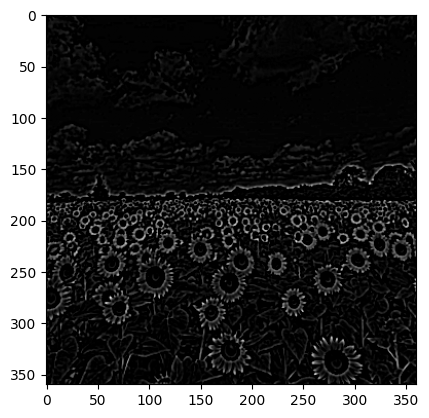

2 13
[[-1.96412803e-05 -6.43310445e-05 -1.64504848e-04 -3.31845109e-04
  -5.36188786e-04 -7.07011010e-04 -7.73522624e-04 -7.07011010e-04
  -5.36188786e-04 -3.31845109e-04 -1.64504848e-04 -6.43310445e-05
  -1.96412803e-05]
 [-6.43310445e-05 -2.01627115e-04 -4.87971972e-04 -9.22278230e-04
  -1.39168823e-03 -1.73562380e-03 -1.85745723e-03 -1.73562380e-03
  -1.39168823e-03 -9.22278230e-04 -4.87971972e-04 -2.01627115e-04
  -6.43310445e-05]
 [-1.64504848e-04 -4.87971972e-04 -1.09313417e-03 -1.85745723e-03
  -2.44954374e-03 -2.67304883e-03 -2.69240991e-03 -2.67304883e-03
  -2.44954374e-03 -1.85745723e-03 -1.09313417e-03 -4.87971972e-04
  -1.64504848e-04]
 [-3.31845109e-04 -9.22278230e-04 -1.85745723e-03 -2.62106369e-03
  -2.44839582e-03 -1.42495796e-03 -8.07344453e-04 -1.42495796e-03
  -2.44839582e-03 -2.62106369e-03 -1.85745723e-03 -9.22278230e-04
  -3.31845109e-04]
 [-5.36188786e-04 -1.39168823e-03 -2.44954374e-03 -2.44839582e-03
   0.00000000e+00  3.99325792e-03  6.03327204e-03  3.99325792

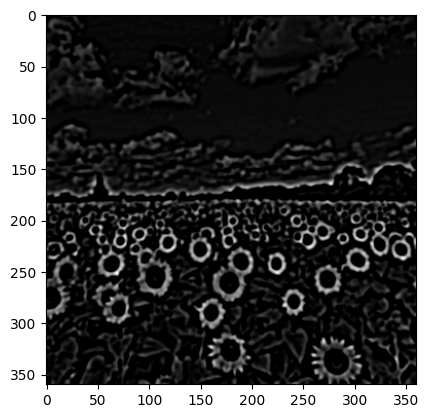

3 19
[[-3.87975908e-06 -8.79858832e-06 -1.78541578e-05 -3.24947848e-05
  -5.32185854e-05 -7.87689374e-05 -1.05913834e-04 -1.30116494e-04
  -1.46831737e-04 -1.52794592e-04 -1.46831737e-04 -1.30116494e-04
  -1.05913834e-04 -7.87689374e-05 -5.32185854e-05 -3.24947848e-05
  -1.78541578e-05 -8.79858832e-06 -3.87975908e-06]
 [-8.79858832e-06 -1.95960696e-05 -3.89414359e-05 -6.92084837e-05
  -1.10409391e-04 -1.58959539e-04 -2.08041461e-04 -2.49686214e-04
  -2.77271245e-04 -2.86874719e-04 -2.77271245e-04 -2.49686214e-04
  -2.08041461e-04 -1.58959539e-04 -1.10409391e-04 -6.92084837e-05
  -3.89414359e-05 -1.95960696e-05 -8.79858832e-06]
 [-1.78541578e-05 -3.89414359e-05 -7.54554148e-05 -1.30116494e-04
  -2.00376949e-04 -2.77271245e-04 -3.48144280e-04 -4.02165372e-04
  -4.34379200e-04 -4.44844482e-04 -4.34379200e-04 -4.02165372e-04
  -3.48144280e-04 -2.77271245e-04 -2.00376949e-04 -1.30116494e-04
  -7.54554148e-05 -3.89414359e-05 -1.78541578e-05]
 [-3.24947848e-05 -6.92084837e-05 -1.30116494e-04 

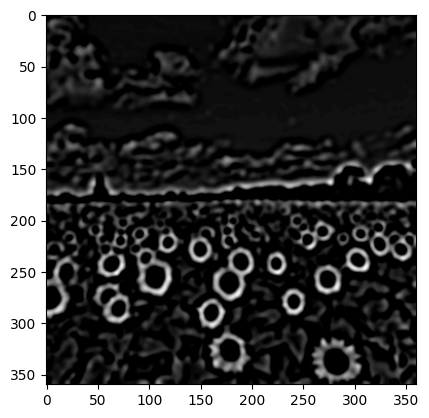

4 25
[[-1.22758002e-06 -2.29252947e-06 -4.02069028e-06 -6.62802926e-06
  -1.02815530e-05 -1.50296015e-05 -2.07403193e-05 -2.70746604e-05
  -3.35117991e-05 -3.94253051e-05 -4.41881881e-05 -4.72761123e-05
  -4.83451640e-05 -4.72761123e-05 -4.41881881e-05 -3.94253051e-05
  -3.35117991e-05 -2.70746604e-05 -2.07403193e-05 -1.50296015e-05
  -1.02815530e-05 -6.62802926e-06 -4.02069028e-06 -2.29252947e-06
  -1.22758002e-06]
 [-2.29252947e-06 -4.23962514e-06 -7.35488222e-06 -1.19791275e-05
  -1.83394641e-05 -2.64332057e-05 -3.59428818e-05 -4.62270800e-05
  -5.64061207e-05 -6.55186479e-05 -7.26909446e-05 -7.72600493e-05
  -7.88268516e-05 -7.72600493e-05 -7.26909446e-05 -6.55186479e-05
  -5.64061207e-05 -4.62270800e-05 -3.59428818e-05 -2.64332057e-05
  -1.83394641e-05 -1.19791275e-05 -7.35488222e-06 -4.23962514e-06
  -2.29252947e-06]
 [-4.02069028e-06 -7.35488222e-06 -1.26016947e-05 -2.02380325e-05
  -3.04982482e-05 -4.31978731e-05 -5.76423894e-05 -7.26909446e-05
  -8.69805146e-05 -9.92282495e-05

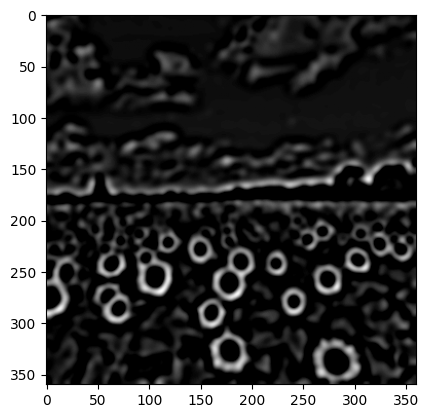

5 31
[[-5.02816777e-07 -8.32941456e-07 -1.32531170e-06 -2.02627092e-06
  -2.97833813e-06 -4.21132411e-06 -5.73268187e-06 -7.51927384e-06
  -9.51293136e-06 -1.16215851e-05 -1.37264329e-05 -1.56940152e-05
  -1.73908077e-05 -1.86975374e-05 -1.95209844e-05 -1.98021792e-05
  -1.95209844e-05 -1.86975374e-05 -1.73908077e-05 -1.56940152e-05
  -1.37264329e-05 -1.16215851e-05 -9.51293136e-06 -7.51927384e-06
  -5.73268187e-06 -4.21132411e-06 -2.97833813e-06 -2.02627092e-06
  -1.32531170e-06 -8.32941456e-07 -5.02816777e-07]
 [-8.32941456e-07 -1.37137893e-06 -2.16750916e-06 -3.28999794e-06
  -4.79826635e-06 -6.72840120e-06 -9.07892719e-06 -1.18001654e-05
  -1.47908031e-05 -1.79037950e-05 -2.09611259e-05 -2.37742331e-05
  -2.61652222e-05 -2.79842349e-05 -2.91203896e-05 -2.95065608e-05
  -2.91203896e-05 -2.79842349e-05 -2.61652222e-05 -2.37742331e-05
  -2.09611259e-05 -1.79037950e-05 -1.47908031e-05 -1.18001654e-05
  -9.07892719e-06 -6.72840120e-06 -4.79826635e-06 -3.28999794e-06
  -2.16750916e-06 -1

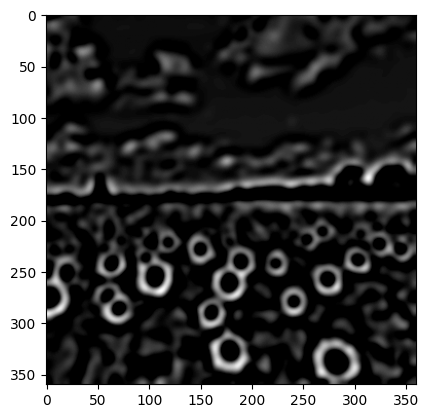

6 37
[[-2.42484943e-07 -3.70318092e-07 -5.49911770e-07 ... -5.49911770e-07
  -3.70318092e-07 -2.42484943e-07]
 [-3.70318092e-07 -5.63175243e-07 -8.32541357e-07 ... -8.32541357e-07
  -5.63175243e-07 -3.70318092e-07]
 [-5.49911770e-07 -8.32541357e-07 -1.22475435e-06 ... -1.22475435e-06
  -8.32541357e-07 -5.49911770e-07]
 ...
 [-5.49911770e-07 -8.32541357e-07 -1.22475435e-06 ... -1.22475435e-06
  -8.32541357e-07 -5.49911770e-07]
 [-3.70318092e-07 -5.63175243e-07 -8.32541357e-07 ... -8.32541357e-07
  -5.63175243e-07 -3.70318092e-07]
 [-2.42484943e-07 -3.70318092e-07 -5.49911770e-07 ... -5.49911770e-07
  -3.70318092e-07 -2.42484943e-07]]


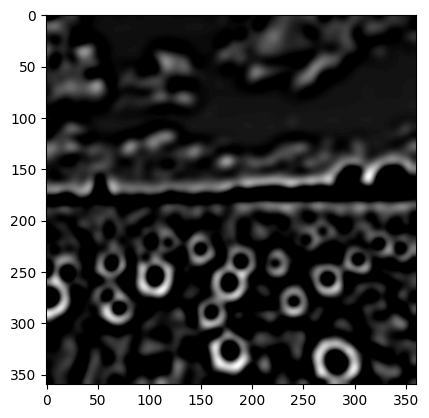

7 43
[[-1.30887333e-07 -1.88479881e-07 -2.65876725e-07 ... -2.65876725e-07
  -1.88479881e-07 -1.30887333e-07]
 [-1.88479881e-07 -2.70587623e-07 -3.80465972e-07 ... -3.80465972e-07
  -2.70587623e-07 -1.88479881e-07]
 [-2.65876725e-07 -3.80465972e-07 -5.33111879e-07 ... -5.33111879e-07
  -3.80465972e-07 -2.65876725e-07]
 ...
 [-2.65876725e-07 -3.80465972e-07 -5.33111879e-07 ... -5.33111879e-07
  -3.80465972e-07 -2.65876725e-07]
 [-1.88479881e-07 -2.70587623e-07 -3.80465972e-07 ... -3.80465972e-07
  -2.70587623e-07 -1.88479881e-07]
 [-1.30887333e-07 -1.88479881e-07 -2.65876725e-07 ... -2.65876725e-07
  -1.88479881e-07 -1.30887333e-07]]


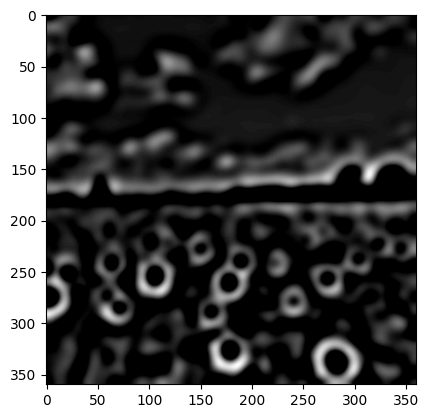

8 49
[[-7.67237514e-08 -1.05679790e-07 -1.43283092e-07 ... -1.43283092e-07
  -1.05679790e-07 -7.67237514e-08]
 [-1.05679790e-07 -1.45227156e-07 -1.96421855e-07 ... -1.96421855e-07
  -1.45227156e-07 -1.05679790e-07]
 [-1.43283092e-07 -1.96421855e-07 -2.64976571e-07 ... -2.64976571e-07
  -1.96421855e-07 -1.43283092e-07]
 ...
 [-1.43283092e-07 -1.96421855e-07 -2.64976571e-07 ... -2.64976571e-07
  -1.96421855e-07 -1.43283092e-07]
 [-1.05679790e-07 -1.45227156e-07 -1.96421855e-07 ... -1.96421855e-07
  -1.45227156e-07 -1.05679790e-07]
 [-7.67237514e-08 -1.05679790e-07 -1.43283092e-07 ... -1.43283092e-07
  -1.05679790e-07 -7.67237514e-08]]


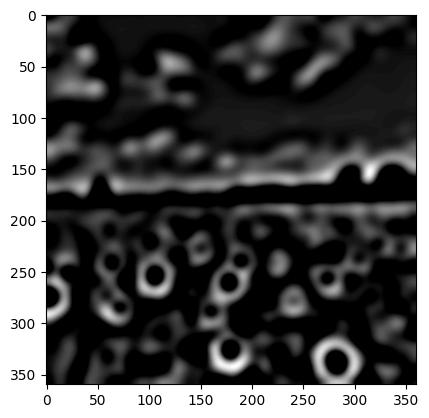

In [77]:
sigma = [0.49, 1, 2, 3, 4, 5, 6, 7, 8]
for s in sigma:
  r = s / np.sqrt(2)
  filter_size = int(6*s + 1)
  print(s, filter_size)
  X, Y = np.meshgrid(np.arange(-filter_size//2+1, filter_size//2+1, 1), np.arange(-filter_size//2+1, filter_size//2+1, 1))
  LoG = (1 / (np.pi * s**4)) * (1 - ((X**2 + Y**2) / (2 * s**2))) * np.exp(- (X**2 + Y**2) / (2 * s**2))
  print(LoG)
  out_img = cv.filter2D(sunflower_gray, -1 , s**2*LoG)
  plt.imshow(out_img, cmap='gray')
  plt.show()


Processing scale with sigma = 1.0
Processing scale with sigma = 1.3333333333333333
Processing scale with sigma = 1.6666666666666665
Processing scale with sigma = 2.0


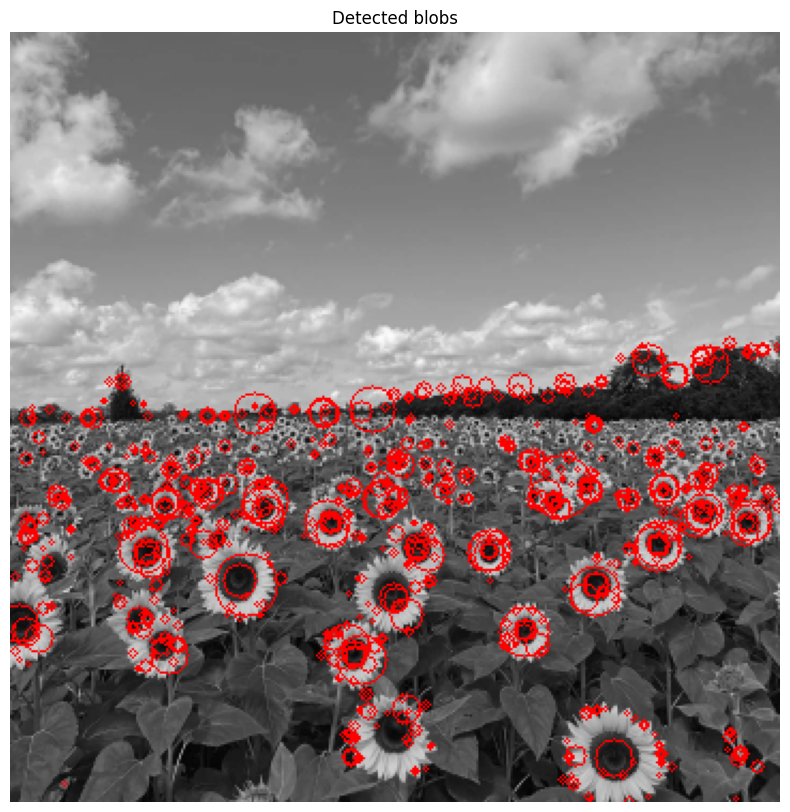

In [59]:
# Select range of sigma
sigma_values = np.linspace(1, 2, 4)
# Threhsold for blob detection
threshold = 0.35

# Store responses of each scale
blob_responses = []

for sigma in sigma_values:
    print(f"Processing scale with sigma = {sigma}")

    # Apply Gaussian blur
    gaussian_blur = cv.GaussianBlur(sunflower_gray, (0, 0), sigma)
    
    # Compute Laplacian of Gaussian (LoG)
    laplacian = cv.Laplacian(gaussian_blur, cv.CV_64F)

    # Get absolute value
    blob_response = np.abs(laplacian)

    # Threshold the response and get contours
    mask = blob_response > threshold * blob_response.max()
    contours, _ = cv.findContours(mask.astype(np.uint8), cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    # Draw contours as circles
    for contour in contours:
        if len(contour) >= 5:
            # Get the center and radius of the enclosing circle from contour
            (center_x, center_y), radius = cv.minEnclosingCircle(contour)
            # Convert to integers
            center = (int(center_x), int(center_y))
            radius = int(radius)
            blob_responses.append((center, radius, sigma))
            # Draw all detected circles with the specified line thickness
output = cv.cvtColor(sunflower_gray, cv.COLOR_GRAY2BGR)
for blob in blob_responses:
    center, radius, _ = blob
    cv.circle(output, center, radius, (0, 0, 255), 1)

# Display the grayscale image with detected circles
plt.figure(figsize=(10, 10))
plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB), cmap='gray')
plt.axis('off')
plt.title('Detected blobs')
plt.show()




0.71,log filter size for 0.7072135785007072 is : (5, 5)
1.41,log filter size for 1.4144271570014144 is : (9, 9)
2.12,log filter size for 2.1216407355021216 is : (13, 13)
2.83,log filter size for 2.828854314002829 is : (17, 17)
3.54,log filter size for 3.5360678925035365 is : (23, 23)
4.24,log filter size for 4.243281471004243 is : (27, 27)
4.95,log filter size for 4.9504950495049505 is : (31, 31)
5.66,log filter size for 5.657708628005658 is : (35, 35)
6.36,log filter size for 6.364922206506365 is : (39, 39)
7.07,log filter size for 7.072135785007073 is : (43, 43)


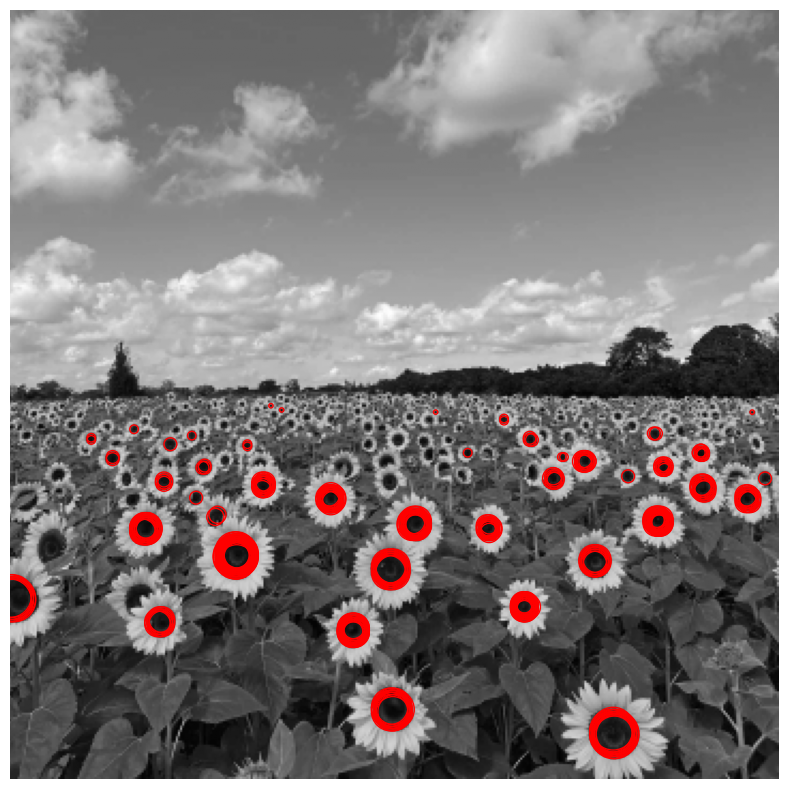

In [40]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Load the image and convert it to grayscale
img1 = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
gray = cv.cvtColor(img1, cv.COLOR_BGR2GRAY) / 255

# Display the grayscale image with detected circles
plt.figure(figsize=(10, 10), frameon=False)
plt.imshow(gray, cmap='gray')
plt.axis('off')

# Get the current axes object
ax = plt.gca()

patches = []
labels = []

# Detect blobs at different sigma values
for r in range(1, 11):
    sigma = r / 1.414
    print(f"{sigma:.2f}", end=",")
    hw = round(3 * sigma)  # Half width of the kernel
    X, Y = np.meshgrid(np.arange(-hw, hw + 1, 1), np.arange(-hw, hw + 1, 1))

    # Calculate Laplacian of Gaussian (LoG) filter
    LOG = ((X**2 + Y**2) / (2 * sigma**2) - 1) * np.exp(-(X**2 + Y**2) / (2 * sigma**2)) / (np.pi * sigma**4)
    print(f'log filter size for {sigma} is :',LOG.shape)
    
    # Scale the filter and apply it to the image
    LOG = sigma**2 * LOG
    img1_log = np.square(cv.filter2D(gray, -1, LOG))

    # Detect maxima manually
    coordinates = []
    (H, W) = img1_log.shape
    k = 1  # Neighborhood size
    threshold = 0.1  # Threshold for maxima detection
    for i in range(k, H - k):
        for j in range(k, W - k):
            slice_img = img1_log[i - k:i + k + 1, j - k:j + k + 1]
            if np.max(slice_img) >= threshold:
                # Get coordinates of the maximum point
                x, y = np.unravel_index(slice_img.argmax(), slice_img.shape)
                coordinates.append((i + x - k, j + y - k))
    coordinates = set(coordinates)

    # Plot circles around detected blobs
    for x, y in coordinates:
        c = plt.Circle((y, x), sigma * 1.414, color='r', linewidth=1, fill=False)
        ax.add_patch(c)
    patches.append(c)
    ax.plot()

ax.set_xlim([0, img1.shape[1]])
ax.set_ylim([img1.shape[0], 0])

# Add legend and title
plt.axis('off')
plt.show()